<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Untitled6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AQUI EMPIEZA

---

**Install Packages**

---

In [1]:
# Install required packages (in case they're not available)
!pip install -q scipy scikit-learn pandas

import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.fft import fft
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestRegressor  # Import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error  # Import mean_squared_error


---

**Simulate signal**

---

In [2]:
# Simulate synthetic vibration signal
fs = 1000  # Sampling frequency
t = np.linspace(0, 10, fs * 10)
signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.random.randn(len(t))  # 50 Hz sine + noise

---

**Visualize Data**

---

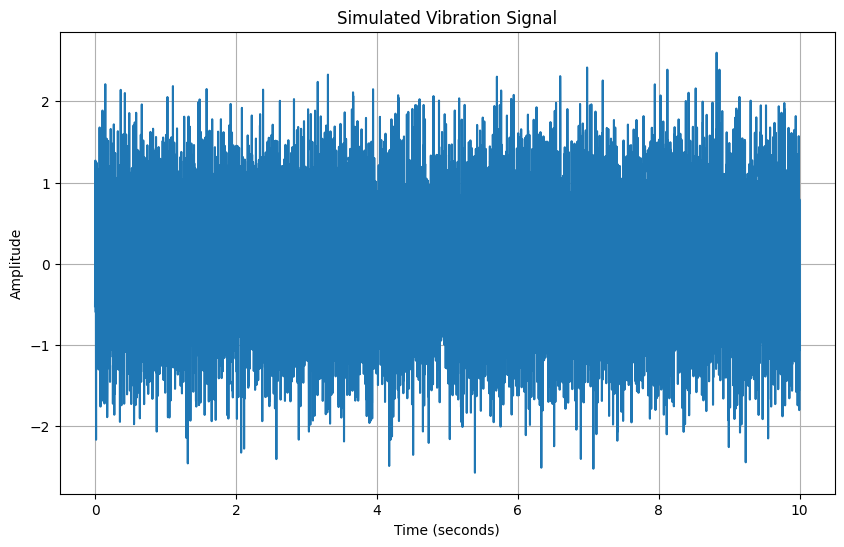

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.plot(t, signal)
plt.title('Simulated Vibration Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

---

**Filtering Data**

---

In [4]:
# Bandpass filter
def bandpass_filter(data, lowcut=10.0, highcut=490.0, fs=1000, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

filtered_signal = bandpass_filter(signal)

---

**Visualize Filtered Data**

---

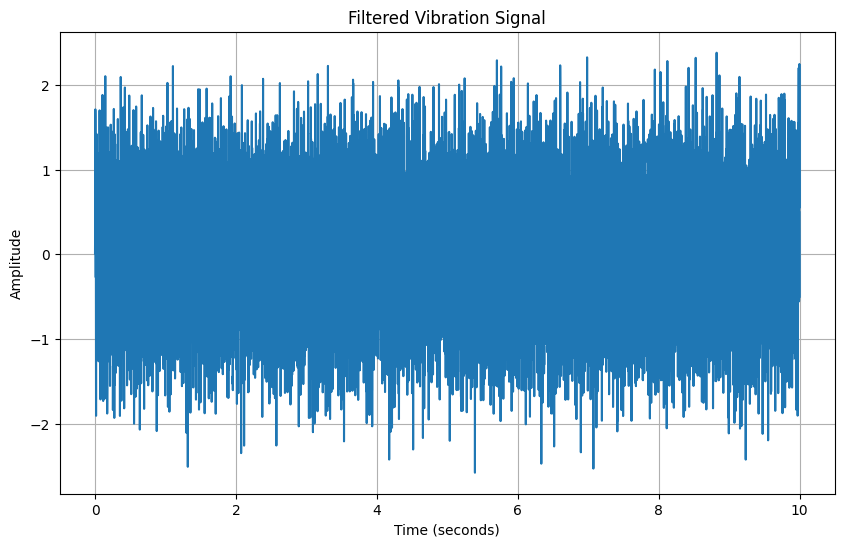

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.plot(t, filtered_signal)
plt.title('Filtered Vibration Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

---

**Feature Selection**

---

The function extract_features(sig, fs) is designed to summarize important characteristics of a vibration signal (or any other time-domain signal) into a compact set of numerical features that are useful for classification or prediction — especially when training machine learning models for fault detection or failure prediction.

Raw signals (like vibrations from an engine) are usually long sequences of numbers. Machine learning models work best when you provide them with fixed-size, informative features that describe each sample. This function does exactly that — it turns a signal segment into a set of descriptive statistics.

Here’s what each part of the function does and why it matters:

1. RMS (Root Mean Square)

  - Measures the energy or power of the signal.

  - Useful to detect increases in vibration energy, which could mean wear or imbalance.

2. Peak

  - Finds the maximum absolute value in the signal.

  - Useful to detect sudden spikes or shocks — common right before failure.

3. Skewness

  - Measures asymmetry of the signal’s distribution.

  - Changes in skewness may indicate nonlinear or abnormal vibrations.

4. Kurtosis

  - Measures the "tailedness" of the distribution.

  - High kurtosis often indicates the presence of impacts or faults (like cracks, misalignment).

5. Spectral Centroid

  - Represents the center of mass of the signal’s frequency spectrum.

  - Helps distinguish between low-frequency and high-frequency dominated signals (e.g., normal vs faulty).

In [6]:
# Feature extraction
def extract_features(sig, fs):
    N = len(sig)
    freqs = np.fft.fftfreq(N, d=1/fs)
    fft_vals = np.abs(fft(sig))

    features = {
        "RMS": np.sqrt(np.mean(sig**2)),
        "Peak": np.max(np.abs(sig)),
        "Skewness": skew(sig),
        "Kurtosis": kurtosis(sig),
        "Spectral Centroid": np.sum(freqs[:N//2] * fft_vals[:N//2]) / np.sum(fft_vals[:N//2])
    }
    return features


---

**RLU (Remaining Useful Life) Predicting**

---

Aplica una ventana deslizante (sliding window) sobre una señal continua (por ejemplo, una vibración del motor) para:

1. Dividir la señal en segmentos de tamaño fijo (window_size = 1024).

2. Extraer características estadísticas de cada segmento usando la función extract_features.

3. Asociar a cada segmento una etiqueta de RUL que indica cuántos segmentos quedan antes de que ocurra un fallo.

4. Guardar los resultados en un DataFrame listo para entrenar modelos de regresión que predigan la RUL.

In [7]:
# Sliding window for RUL prediction
window_size = 1024
features_list_rul = []  # Separate list for RUL features
labels_rul = []  # Separate list for RUL labels

total_windows = len(filtered_signal) // window_size

for i in range(total_windows):
    window = filtered_signal[i * window_size:(i + 1) * window_size]
    features = extract_features(window, fs)
    features_list_rul.append(features)
    # Etiqueta de vida restante
    remaining = total_windows - i
    rul = max(0, remaining - 5)  # Supón que los últimos 5 bloques son fallo inminente
    labels_rul.append(rul)

feature_df_rul = pd.DataFrame(features_list_rul)
feature_df_rul['rul'] = labels_rul

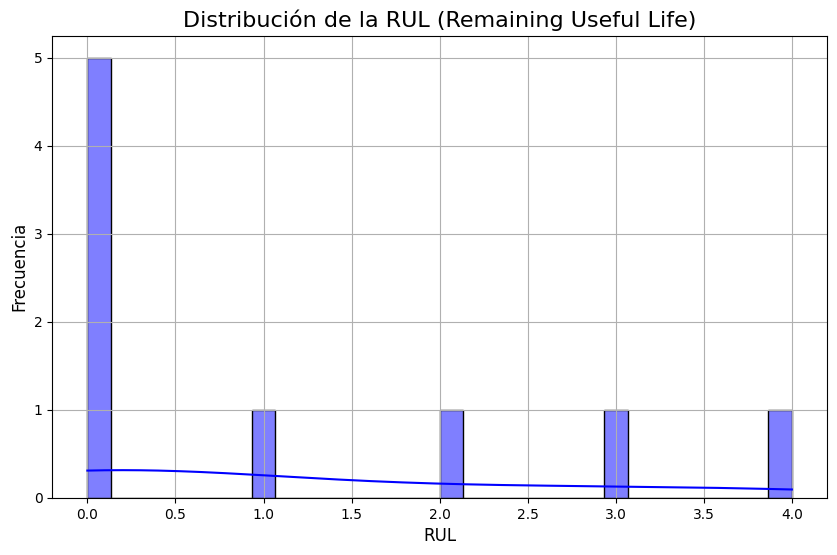

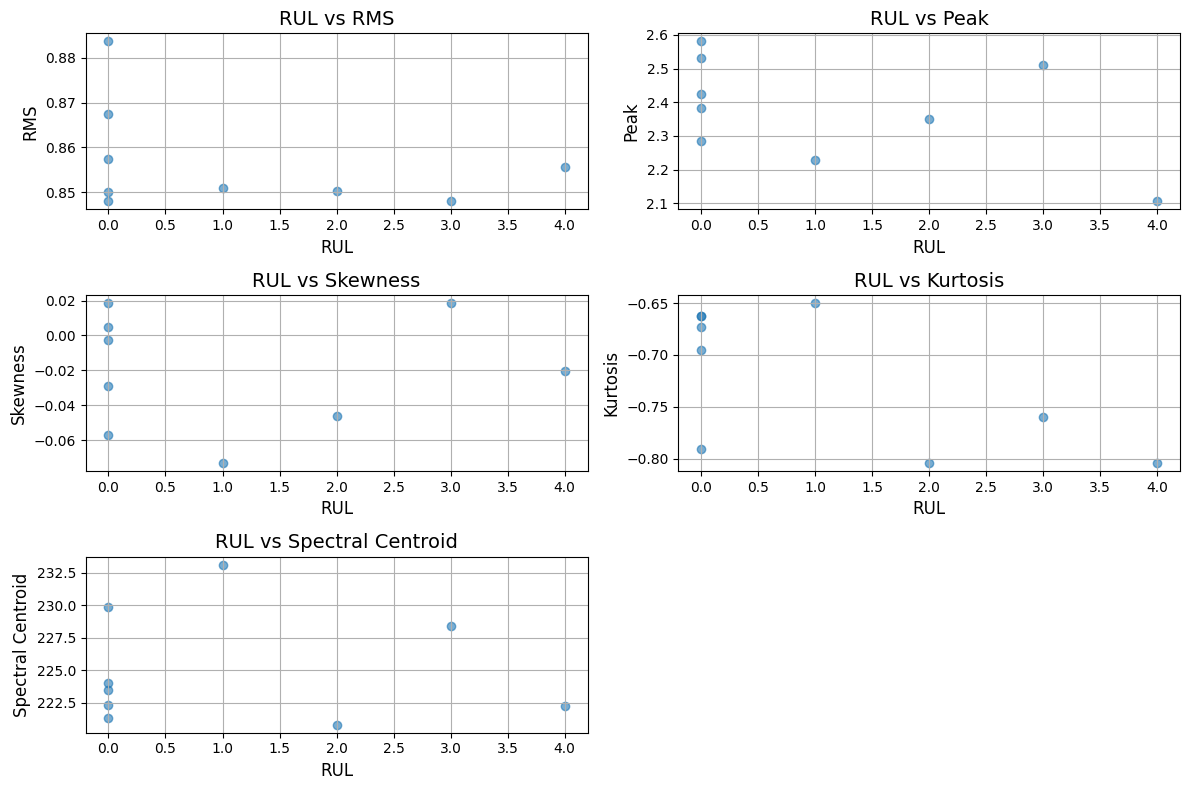

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualización 1: Distribución de la RUL ---
plt.figure(figsize=(10, 6))
sns.histplot(feature_df_rul['rul'], kde=True, color='blue', bins=30)
plt.title('Distribución de la RUL (Remaining Useful Life)', fontsize=16)
plt.xlabel('RUL', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.grid(True)
plt.show()

# --- Visualización 2: RUL vs primeras 5 características ---
plt.figure(figsize=(12, 8))
for i, col in enumerate(feature_df_rul.columns[:-1][:5], 1):  # Las primeras 5 características
    plt.subplot(3, 2, i)
    plt.scatter(feature_df_rul['rul'], feature_df_rul[col], alpha=0.6)
    plt.title(f'RUL vs {col}', fontsize=14)
    plt.xlabel('RUL', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.grid(True)

plt.tight_layout()
plt.show()

---

**Train-test split**

---

In [10]:
# Train-test split and model training for RUL prediction
X_rul = feature_df_rul.drop('rul', axis=1)
y_rul = feature_df_rul['rul']
X_train_rul, X_test_rul, y_train_rul, y_test_rul = train_test_split(X_rul, y_rul, test_size=0.2, random_state=42)


---

**Use RandomForestRegressor for RUL prediction**

---

In [11]:
# Use RandomForestRegressor for RUL prediction
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train_rul, y_train_rul)

RandomForestRegressor(random_state=42)

---

**Prediction on a new signal**

---

In [12]:
# Prediction on a new signal
new_window = filtered_signal[-window_size:]  # última ventana
new_feat = extract_features(new_window, fs)
new_df = pd.DataFrame([new_feat])
predicted_rul = regressor.predict(new_df)  # Use the regressor for prediction
print(f"🔧 Tiempo restante estimado hasta fallo: {predicted_rul[0]}")

🔧 Tiempo restante estimado hasta fallo: 0.89


In [15]:
# Evaluate RUL prediction (e.g., using mean squared error)
y_pred_rul = regressor.predict(X_test_rul)
mse = mean_squared_error(y_test_rul, y_pred_rul)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 4.187200000000001


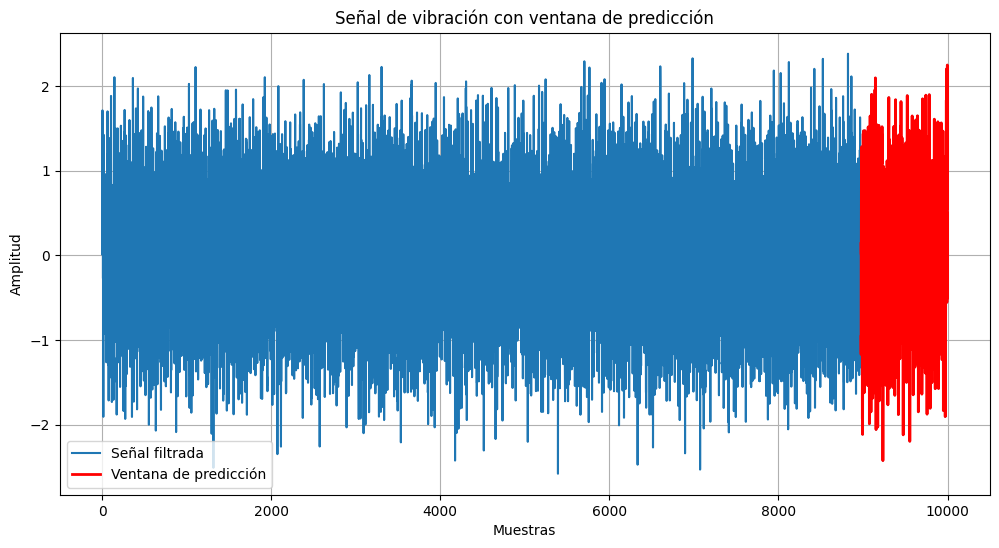

🔧 Tiempo restante estimado hasta fallo: 0.89
Mean Squared Error: 4.187200000000001


In [16]:
from sklearn.metrics import mean_squared_error

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(filtered_signal, label='Señal filtrada')
plt.plot(range(len(filtered_signal) - window_size, len(filtered_signal)),
         filtered_signal[-window_size:], label='Ventana de predicción', color='red', linewidth=2)
plt.title('Señal de vibración con ventana de predicción')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

print(f"🔧 Tiempo restante estimado hasta fallo: {predicted_rul[0]}")
print(f"Mean Squared Error: {mse}")